In [1]:
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from transformers import AutoTokenizer, AutoModel

# Load the pre-trained model and tokenizer
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

c:\Users\dukes\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\dukes\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
words = [
    "market", "stock", "trade", "profit", "loss", 
    "buy", "sell", "risk", "asset", "value",
    "algorithm", "data", "network", "python", "code",
    "chart", "trend", "gold", "tech", "bank"
]

word_ids = [tokenizer.encode(w, add_special_tokens=False)[0] for w in words]

In [ ]:
embeddings = model.embeddings.word_embeddings.weight[word_ids].detach().numpy()

pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(embeddings)

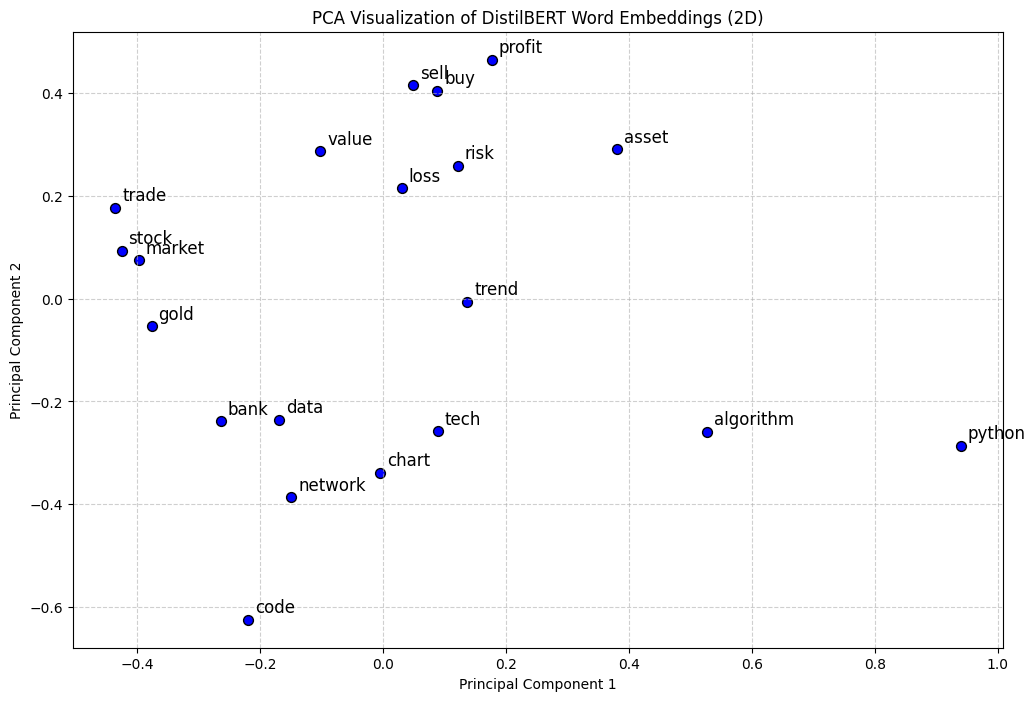

In [ ]:
plt.figure(figsize=(12, 8))

plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], color='blue', edgecolors='k', s=50)

for i, word in enumerate(words):
    plt.annotate(
        word, 
        (vectors_2d[i, 0], vectors_2d[i, 1]),
        xytext=(5, 5), 
        textcoords='offset points',
        fontsize=12
    )

plt.title("PCA Visualization of DistilBERT Word Embeddings (2D)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, linestyle='--', alpha=0.6)

# Show the graph
plt.show()